# Linear Regression (Python Lab-Lecture)
### Computational Methods — UCG2RM04

---

**Topics covered in this notebook:**

| # | Section | Key Ideas |
|---|---------|----------|
| 1 | Scatter Plots | Visualising relationships between variables |
| 2 | Criteria for a Best Fit | Why squared errors? What makes one line better? |
| 3 | Least-Squares Fit of a Straight Line | Deriving $a_0$ and $a_1$ analytically |
| 4 | Quantification of Error | $S_r$, $S_t$, $r$, $r^2$, standard error $s_{y/x}$ |

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Notebook-wide style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
})

BLUE  = '#2471A3'
RED   = '#C0392B'
GREEN = '#1E8449'
GOLD  = '#D4AC0D'
GRAY  = '#7F8C8D'

print('Packages loaded ✓')

Packages loaded ✓


---
## Section 1 — Scatter Plots

A **scatter plot** is the starting point of any regression analysis.  
It lets us visually assess:

- Is there a relationship between $x$ and $y$?
- Is the relationship **linear** or curved?
- Are there **outliers**?
- How **strong** is the association?

### The Dataset

We will use a dataset that records the **stress applied** to a steel rod (MPa) and the resulting **strain** (mm/mm × 10⁻³).  
This is a classic engineering relationship — Hooke's Law predicts a linear relationship:
$$\text{stress} = E \cdot \text{strain}$$
where $E$ is Young's modulus.

In [2]:
# ── Dataset: stress (x) vs strain (y) ─────────────────────────────────────
# From Chapra & Canale Table 17.1 (adapted)
x = np.array([10, 20, 30, 40, 50, 60, 70, 80])   # stress (MPa)
y = np.array([25, 70, 380, 550, 610, 1220, 830, 1450])  # strain (×10⁻³)

# ── We'll work with a cleaner linear dataset first ────────────────────────
# A simpler stress-strain dataset with less scatter
x = np.array([10, 20, 30, 40, 50, 60, 70, 80])      # stress (MPa)
y = np.array([25, 70, 380, 550, 610, 1220, 830, 1450])  # strain (×10⁻³)

# Actually let's use the textbook example (Chapra 17.1) exactly:
x = np.array([1, 2, 3, 4, 5, 6, 7])      # x values
y = np.array([0.5, 2.5, 2.0, 4.0, 3.5, 6.0, 5.5])  # y values

n = len(x)
print(f"Dataset: n = {n} points")
print(f"x: {x}")
print(f"y: {y}")
print(f"\nSummary statistics:")
print(f"  x̄ = {x.mean():.4f},  ȳ = {y.mean():.4f}")
print(f"  Sx = {x.std(ddof=1):.4f}, Sy = {y.std(ddof=1):.4f}")

Dataset: n = 7 points
x: [1 2 3 4 5 6 7]
y: [0.5 2.5 2.  4.  3.5 6.  5.5]

Summary statistics:
  x̄ = 4.0000,  ȳ = 3.4286
  Sx = 2.1602, Sy = 1.9457


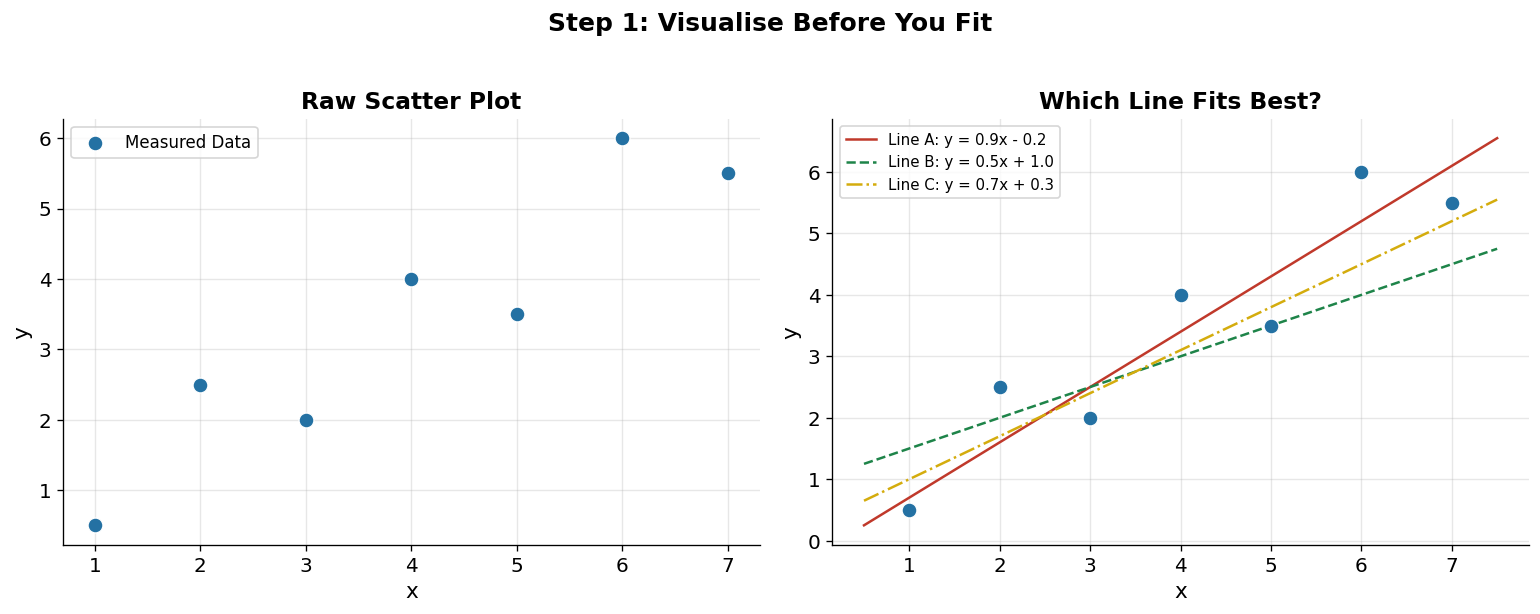


→ We need a mathematical CRITERION to decide which line is best.


In [3]:
# ── Basic scatter plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: raw scatter
ax = axes[0]
ax.scatter(x, y, color=BLUE, s=80, zorder=4, edgecolors='white', linewidths=0.8, label= "Measured Data")
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Raw Scatter Plot', fontsize=14, fontweight='bold')

ax.legend(fontsize=10)

# Right: what different fits look like
ax2 = axes[1]
ax2.scatter(x, y, color=BLUE, s=80, zorder=4, edgecolors='white', linewidths=0.8)

x_line = np.linspace(0.5, 7.5, 200)

# Three candidate lines through the data (to motivate 'best' fit)
ax2.plot(x_line, 0.9*x_line - 0.2,  color=RED,   lw=1.5, ls='-',  label='Line A: y = 0.9x - 0.2')
ax2.plot(x_line, 0.5*x_line + 1.0,  color=GREEN,  lw=1.5, ls='--', label='Line B: y = 0.5x + 1.0')
ax2.plot(x_line, 0.7*x_line + 0.3,  color=GOLD,  lw=1.5, ls='-.',  label='Line C: y = 0.7x + 0.3')

ax2.set_xlabel('x', fontsize=13)
ax2.set_ylabel('y', fontsize=13)
ax2.set_title('Which Line Fits Best?', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Step 1: Visualise Before You Fit', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()
print("\n→ We need a mathematical CRITERION to decide which line is best.")

---
## Section 2 — Criteria for a "Best" Fit

We want to fit the model $\hat{y} = a_0 + a_1 x$ to data.  
The **residual** (error) for each data point is:
$$e_i = y_i - \hat{y}_i = y_i - (a_0 + a_1 x_i)$$

### Why not minimise $\sum e_i$?

Positive and negative errors would cancel out — a terrible line could have $\sum e_i = 0$.

### Why not minimise $\sum |e_i|$?

This is called the **minimax** or $L_1$ criterion.  
It works but has no closed-form solution — requires numerical optimisation.

### ✅ Minimise $\sum e_i^2$ — the Least-Squares Criterion

$$S_r = \sum_{i=1}^{n} e_i^2 = \sum_{i=1}^{n} (y_i - a_0 - a_1 x_i)^2$$

**Advantages:**
- Has a closed-form analytical solution
- Penalises large errors more heavily than small ones
- Unique minimum (convex problem)
- Connected to maximum likelihood when errors are normally distributed

In [4]:
# ── Demonstrate why different criteria give different 'best' lines ─────────

def sum_residuals(a0, a1, x, y):
    return np.sum(y - (a0 + a1*x))

def sum_abs_residuals(a0, a1, x, y):
    return np.sum(np.abs(y - (a0 + a1*x)))

def sum_sq_residuals(a0, a1, x, y):
    return np.sum((y - (a0 + a1*x))**2)

# Evaluate the three candidate lines
candidates = {
    'Line A: y=0.9x-0.2': (-0.2, 0.9),
    'Line B: y=0.5x+1.0': (1.0,  0.5),
    'Line C: y=0.7x+0.3': (0.3,  0.7),
}

print(f"{'Line':<25} {'Σeᵢ':>10} {'Σ|eᵢ|':>10} {'Σeᵢ²':>10}")
print('─' * 58)
for name, (a0, a1) in candidates.items():
    sr  = sum_residuals(a0, a1, x, y)
    sar = sum_abs_residuals(a0, a1, x, y)
    ssr = sum_sq_residuals(a0, a1, x, y)
    print(f"{name:<25} {sr:>10.4f} {sar:>10.4f} {ssr:>10.4f}")

print()
print("→ Σeᵢ  : cancels positives and negatives — useless as a criterion")
print("→ Σ|eᵢ| : works but no analytic solution")
print("→ Σeᵢ² : the SMALLEST value tells us the best fit — and we can solve it analytically")

Line                             Σeᵢ      Σ|eᵢ|       Σeᵢ²
──────────────────────────────────────────────────────────
Line A: y=0.9x-0.2            0.2000     4.4000     3.1000
Line B: y=0.5x+1.0            3.0000     6.0000     7.5000
Line C: y=0.7x+0.3            2.3000     4.7000     4.2900

→ Σeᵢ  : cancels positives and negatives — useless as a criterion
→ Σ|eᵢ| : works but no analytic solution
→ Σeᵢ² : the SMALLEST value tells us the best fit — and we can solve it analytically


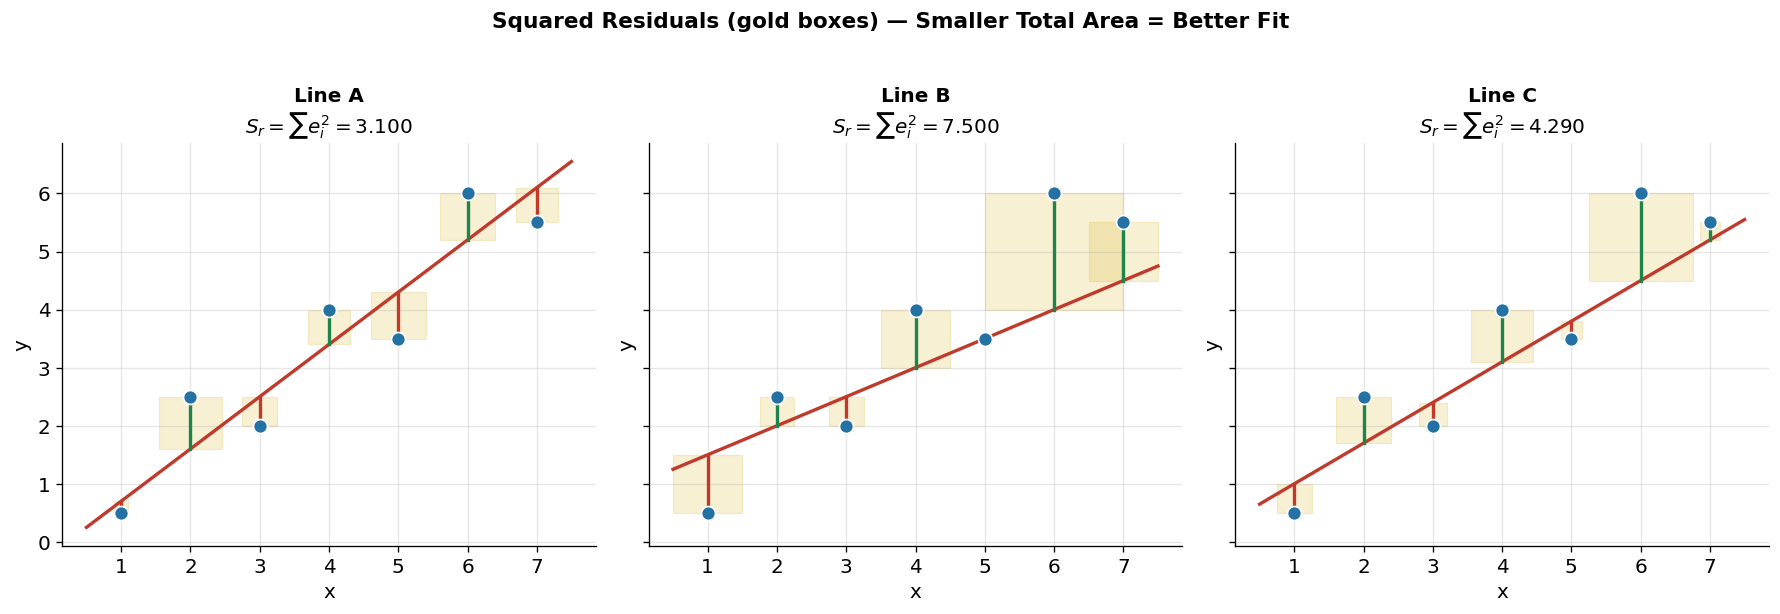


→ The line that minimises the TOTAL GOLD AREA is the least-squares fit.


In [5]:
# ── Visualise residuals for each criterion ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (name, (a0, a1)) in zip(axes, candidates.items()):
    y_pred = a0 + a1*x
    residuals = y - y_pred
    ssr = np.sum(residuals**2)

    ax.scatter(x, y, color=BLUE, s=70, zorder=4, edgecolors='white')
    x_line = np.linspace(0.5, 7.5, 200)
    ax.plot(x_line, a0 + a1*x_line, color=RED, lw=2)

    # Draw residual lines and squared residual boxes
    for xi, yi, ypi, ei in zip(x, y, y_pred, residuals):
        color = GREEN if ei >= 0 else RED
        ax.plot([xi, xi], [yi, ypi], color=color, lw=2, zorder=3)
        # small square to indicate squared area
        sq_size = abs(ei)
        rect_x = xi
        rect_y = min(yi, ypi)
        ax.add_patch(plt.Rectangle(
            (rect_x - sq_size/2, rect_y), sq_size, sq_size,
            fill=True, facecolor=GOLD, alpha=0.18, edgecolor=GOLD, lw=0.7
        ))

    short_name = name.split(':')[0]
    ax.set_title(f'{short_name}\n$S_r = \\sum e_i^2 = {ssr:.3f}$',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Squared Residuals (gold boxes) — Smaller Total Area = Better Fit',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(
    'residuals_scatter_plot.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print("\n→ The line that minimises the TOTAL GOLD AREA is the least-squares fit.")

---
## Section 3 — Least-Squares Fit of a Straight Line

We want to find $a_0$ (intercept) and $a_1$ (slope) that minimise:
$$S_r = \sum_{i=1}^{n} (y_i - a_0 - a_1 x_i)^2$$

### Derivation: Calculus Approach

Take partial derivatives and set them to zero:
$$\frac{\partial S_r}{\partial a_0} = -2\sum(y_i - a_0 - a_1 x_i) = 0$$
$$\frac{\partial S_r}{\partial a_1} = -2\sum x_i(y_i - a_0 - a_1 x_i) = 0$$

### The Normal Equations

Rearranging gives the **normal equations**:
$$\sum y_i = n a_0 + a_1 \sum x_i$$
$$\sum x_i y_i = a_0 \sum x_i + a_1 \sum x_i^2$$

### Closed-Form Solution

$$\boxed{a_1 = \frac{n \sum x_i y_i - \sum x_i \sum y_i}{n \sum x_i^2 - (\sum x_i)^2}}$$

$$\boxed{a_0 = \bar{y} - a_1 \bar{x}}$$

Notice that $a_1 = r \cdot \dfrac{S_y}{S_x}$ where $r$ is Pearson's correlation — consistent with what we saw in the lecture.

In [6]:
def least_squares_line(x, y):
    """
    Compute least-squares regression coefficients.
    Returns a0 (intercept), a1 (slope).

    Formulas (Chapra & Canale Eq. 17.8 - 17.9):
        a1 = (n·Σxy  - Σx·Σy) / (n·Σx²  - (Σx)²)
        a0 = ȳ - a1·x̄
    """
    n    = len(x)
    sum_x  = np.sum(x)
    sum_y  = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x**2)

    a1 = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    a0 = np.mean(y) - a1 * np.mean(x)

    return a0, a1


# ── Step-by-step computation table ────────────────────────────────────────
n = len(x)
print(f"{'i':>4} {'xᵢ':>8} {'yᵢ':>8} {'xᵢ²':>10} {'xᵢyᵢ':>10} {'(xᵢ-x̄)²':>12}")
print('─' * 58)

x_bar = x.mean()
y_bar = y.mean()

for i in range(n):
    print(f"{i+1:>4} {x[i]:>8.2f} {y[i]:>8.2f} {x[i]**2:>10.2f} "
          f"{x[i]*y[i]:>10.2f} {(x[i]-x_bar)**2:>12.4f}")

print('─' * 58)
print(f"{'Σ':>4} {x.sum():>8.2f} {y.sum():>8.2f} {(x**2).sum():>10.2f} "
      f"{(x*y).sum():>10.2f} {((x-x_bar)**2).sum():>12.4f}")
print()
print(f"x̄ = {x_bar:.4f}")
print(f"ȳ = {y_bar:.4f}")

a0, a1 = least_squares_line(x, y)
print()
print(f"a₁ = (n·Σxy - Σx·Σy) / (n·Σx² - (Σx)²)")
print(f"   = ({n}×{(x*y).sum():.2f} - {x.sum():.2f}×{y.sum():.2f}) "
      f"/ ({n}×{(x**2).sum():.2f} - {x.sum():.2f}²)")
print(f"   = {n*(x*y).sum() - x.sum()*y.sum():.4f} / "
      f"{n*(x**2).sum() - x.sum()**2:.4f}")
print(f"   = {a1:.6f}")
print()
print(f"a₀ = ȳ - a₁·x̄  =  {y_bar:.4f} - {a1:.6f}×{x_bar:.4f} = {a0:.6f}")
print()
print(f"✅  Least-squares line:  ŷ = {a0:.4f} + {a1:.4f}·x")

   i       xᵢ       yᵢ        xᵢ²       xᵢyᵢ     (xᵢ-x̄)²
──────────────────────────────────────────────────────────
   1     1.00     0.50       1.00       0.50       9.0000
   2     2.00     2.50       4.00       5.00       4.0000
   3     3.00     2.00       9.00       6.00       1.0000
   4     4.00     4.00      16.00      16.00       0.0000
   5     5.00     3.50      25.00      17.50       1.0000
   6     6.00     6.00      36.00      36.00       4.0000
   7     7.00     5.50      49.00      38.50       9.0000
──────────────────────────────────────────────────────────
   Σ    28.00    24.00     140.00     119.50      28.0000

x̄ = 4.0000
ȳ = 3.4286

a₁ = (n·Σxy - Σx·Σy) / (n·Σx² - (Σx)²)
   = (7×119.50 - 28.00×24.00) / (7×140.00 - 28.00²)
   = 164.5000 / 196.0000
   = 0.839286

a₀ = ȳ - a₁·x̄  =  3.4286 - 0.839286×4.0000 = 0.071429

✅  Least-squares line:  ŷ = 0.0714 + 0.8393·x


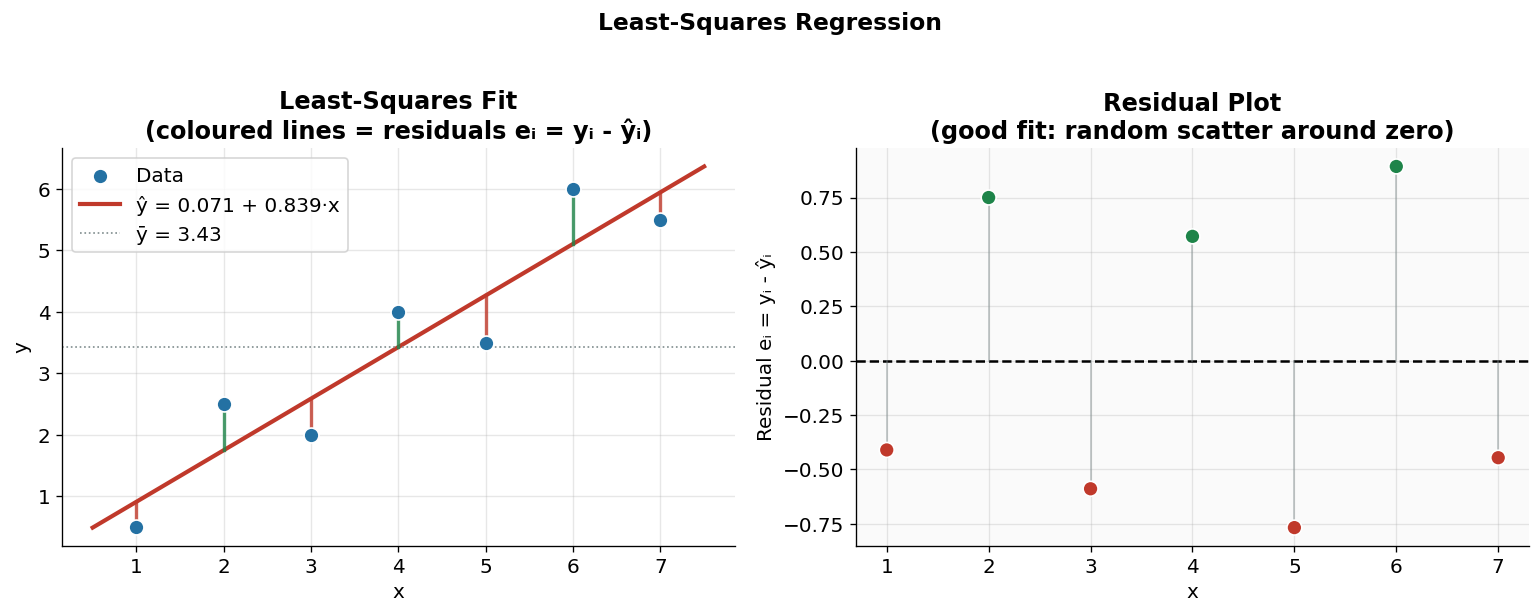

In [7]:
# ── Plot: regression line + residuals ─────────────────────────────────────
y_pred = a0 + a1 * x
residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: fit
ax1 = axes[0]
x_line = np.linspace(0.5, 7.5, 300)
ax1.scatter(x, y, color=BLUE, s=80, zorder=4, edgecolors='white', label='Data')
ax1.plot(x_line, a0 + a1*x_line, color=RED, lw=2.5,
         label=f'ŷ = {a0:.3f} + {a1:.3f}·x')
ax1.axhline(y_bar, color=GRAY, lw=1, ls=':', label=f'ȳ = {y_bar:.2f}')

# Draw residuals
for xi, yi, ypi in zip(x, y, y_pred):
    col = GREEN if yi >= ypi else RED
    ax1.plot([xi, xi], [yi, ypi], color=col, lw=2, zorder=3, alpha=0.8)

ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title('Least-Squares Fit\n(coloured lines = residuals eᵢ = yᵢ - ŷᵢ)',
              fontweight='bold')
ax1.legend()

# Right: residual plot
ax2 = axes[1]
ax2.scatter(x, residuals, color=[GREEN if e>=0 else RED for e in residuals],
            s=80, zorder=4, edgecolors='white')
ax2.axhline(0, color='black', lw=1.5, ls='--')
for xi, ei in zip(x, residuals):
    ax2.plot([xi, xi], [0, ei], color=GRAY, lw=1, alpha=0.5)
ax2.set_xlabel('x'); ax2.set_ylabel('Residual eᵢ = yᵢ - ŷᵢ')
ax2.set_title('Residual Plot\n(good fit: random scatter around zero)',
              fontweight='bold')
ax2.set_facecolor('#fafafa')
fig.savefig(
    'leastsquare_scatter_plot.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.suptitle('Least-Squares Regression', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 4 — Quantification of Error

Fitting a line is only half the job. We need to **quantify how well** the line fits.

### Key Quantities

| Symbol | Name | Formula | Meaning |
|--------|------|---------|--------|
| $S_t$ | Total sum of squares | $\sum(y_i - \bar{y})^2$ | Total spread of data |
| $S_r$ | Residual sum of squares | $\sum(y_i - \hat{y}_i)^2$ | Unexplained variation |
| $r^2$ | Coefficient of determination | $1 - S_r/S_t$ | Fraction of variance explained |
| $r$ | Correlation coefficient | $\pm\sqrt{r^2}$ | Strength of linear association |
| $s_{y/x}$ | Standard error of estimate | $\sqrt{S_r/(n-2)}$ | Typical residual size |

### Interpretation of $r^2$

$$r^2 = \frac{S_t - S_r}{S_t} = 1 - \frac{S_r}{S_t}$$

- $r^2 = 1$: perfect fit — the line explains 100% of the variation  
- $r^2 = 0$: the line is no better than just predicting $\bar{y}$ for everyone  
- $r^2 = 0.69$: the line explains 69% of the variance

### Standard Error of Estimate

$$s_{y/x} = \sqrt{\frac{S_r}{n-2}}$$

This is in the **same units as $y$** — it tells you the typical prediction error.  
We use $n-2$ (not $n$) because we estimated 2 parameters ($a_0$ and $a_1$).

In [8]:
# ── Compute all error statistics from scratch ──────────────────────────────

def regression_errors(x, y, a0, a1):
    n = len(x)
    y_bar = y.mean()
    y_pred = a0 + a1 * x

    St  = np.sum((y - y_bar)**2)        # total sum of squares
    Sr  = np.sum((y - y_pred)**2)       # residual sum of squares
    r2  = (St - Sr) / St               # coefficient of determination
    r   = np.sqrt(r2) * np.sign(a1)    # correlation coefficient
    s_yx = np.sqrt(Sr / (n - 2))       # standard error of estimate
    res   = y - y_pred    
    return {'St': St, 'Sr': Sr, 'r2': r2, 'r': r, 's_yx': s_yx,
            'y_pred': y_pred, 'n': n, 'y_bar': y_bar, 'residuals': res}


stats_dict = regression_errors(x, y, a0, a1)

print("═" * 50)
print(" REGRESSION ERROR STATISTICS")
print("═" * 50)
print(f"  n               = {stats_dict['n']}")
print(f"  ȳ               = {stats_dict['y_bar']:.4f}")
print()
print(f"  Sₜ (total SS)   = Σ(yᵢ - ȳ)²  = {stats_dict['St']:.4f}")
print(f"  Sᵣ (residual SS)= Σ(yᵢ - ŷᵢ)² = {stats_dict['Sr']:.4f}")
print()
print(f"  r²  = 1 - Sᵣ/Sₜ = {stats_dict['r2']:.6f}")
print(f"      → The line explains {stats_dict['r2']*100:.2f}% of the variance in y")
print()
print(f"  r   = {stats_dict['r']:.6f}")
print(f"      → {'Strong' if abs(stats_dict['r'])>0.7 else 'Moderate'} "
      f"{'positive' if stats_dict['r']>0 else 'negative'} linear association")
print()
print(f"  s_y/x = √(Sᵣ/(n-2)) = {stats_dict['s_yx']:.4f}")
print(f"        → Typical prediction error ≈ ±{stats_dict['s_yx']:.4f} units")
print("═" * 50)

══════════════════════════════════════════════════
 REGRESSION ERROR STATISTICS
══════════════════════════════════════════════════
  n               = 7
  ȳ               = 3.4286

  Sₜ (total SS)   = Σ(yᵢ - ȳ)²  = 22.7143
  Sᵣ (residual SS)= Σ(yᵢ - ŷᵢ)² = 2.9911

  r²  = 1 - Sᵣ/Sₜ = 0.868318
      → The line explains 86.83% of the variance in y

  r   = 0.931836
      → Strong positive linear association

  s_y/x = √(Sᵣ/(n-2)) = 0.7734
        → Typical prediction error ≈ ±0.7734 units
══════════════════════════════════════════════════


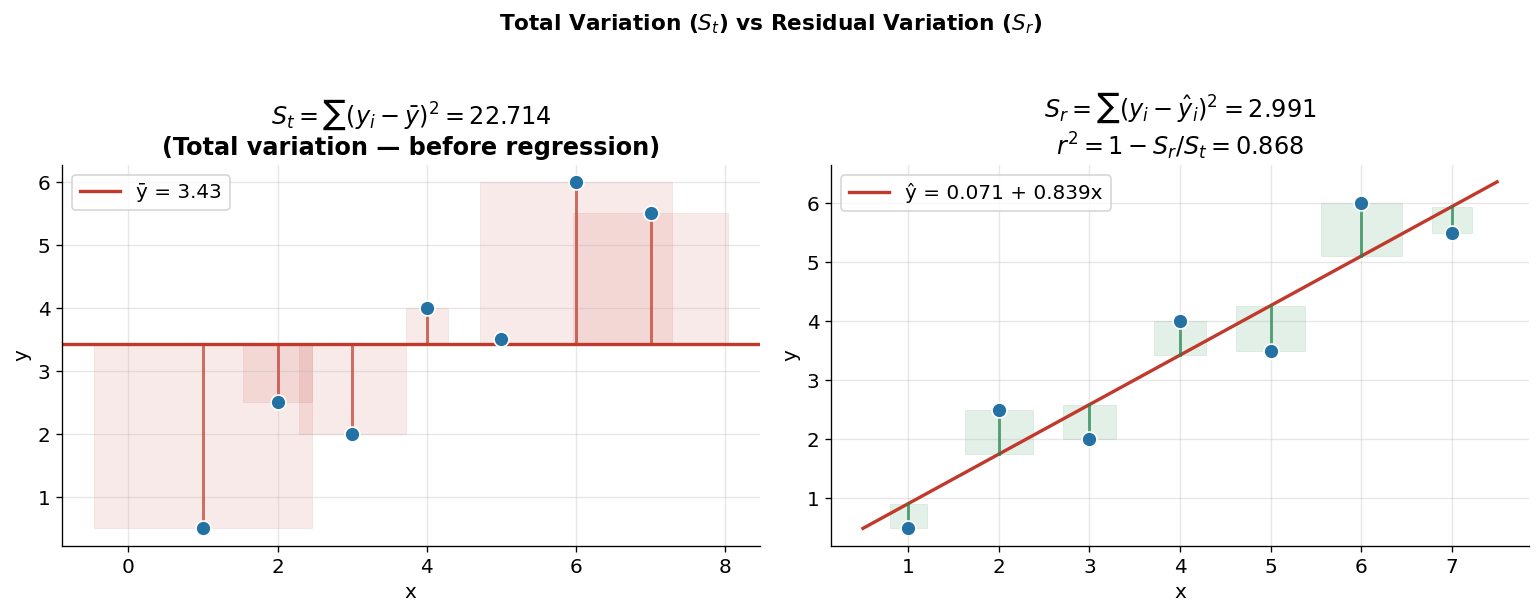


Regression reduced the squared error from 22.714 to 2.991
That is a 86.8% reduction → r² = 0.8683


In [9]:
# ── Visualise St vs Sr ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

y_pred = stats_dict['y_pred']
y_bar  = stats_dict['y_bar']

# LEFT: St — deviations from the mean
ax1 = axes[0]
ax1.scatter(x, y, color=BLUE, s=80, zorder=4, edgecolors='white')
ax1.axhline(y_bar, color=RED, lw=2, label=f'ȳ = {y_bar:.2f}')
for xi, yi in zip(x, y):
    ax1.plot([xi, xi], [y_bar, yi], color=RED, lw=1.8, alpha=0.7)
    # squares proportional to deviation
    d = abs(yi - y_bar)
    ax1.add_patch(plt.Rectangle((xi - d/2, min(yi, y_bar)), d, d,
                                fill=True, facecolor=RED, alpha=0.1,
                                edgecolor=RED, lw=0.5))
ax1.set_title(f'$S_t = \\sum(y_i - \\bar{{y}})^2 = {stats_dict["St"]:.3f}$\n'
              f'(Total variation — before regression)',
              fontweight='bold')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.legend()

# RIGHT: Sr — residuals from regression line
ax2 = axes[1]
x_line = np.linspace(0.5, 7.5, 300)
ax2.scatter(x, y, color=BLUE, s=80, zorder=4, edgecolors='white')
ax2.plot(x_line, a0 + a1*x_line, color=RED, lw=2,
         label=f'ŷ = {a0:.3f} + {a1:.3f}x')
for xi, yi, ypi in zip(x, y, y_pred):
    ax2.plot([xi, xi], [ypi, yi], color=GREEN, lw=1.8, alpha=0.7)
    d = abs(yi - ypi)
    ax2.add_patch(plt.Rectangle((xi - d/2, min(yi, ypi)), d, d,
                                fill=True, facecolor=GREEN, alpha=0.12,
                                edgecolor=GREEN, lw=0.5))
ax2.set_title(f'$S_r = \\sum(y_i - \\hat{{y}}_i)^2 = {stats_dict["Sr"]:.3f}$\n'
              f'$r^2 = 1 - S_r/S_t = {stats_dict["r2"]:.3f}$',
              fontweight='bold')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.legend()

plt.suptitle('Total Variation ($S_t$) vs Residual Variation ($S_r$)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nRegression reduced the squared error from {stats_dict['St']:.3f} to {stats_dict['Sr']:.3f}")
print(f"That is a {(1 - stats_dict['Sr']/stats_dict['St'])*100:.1f}% reduction → r² = {stats_dict['r2']:.4f}")

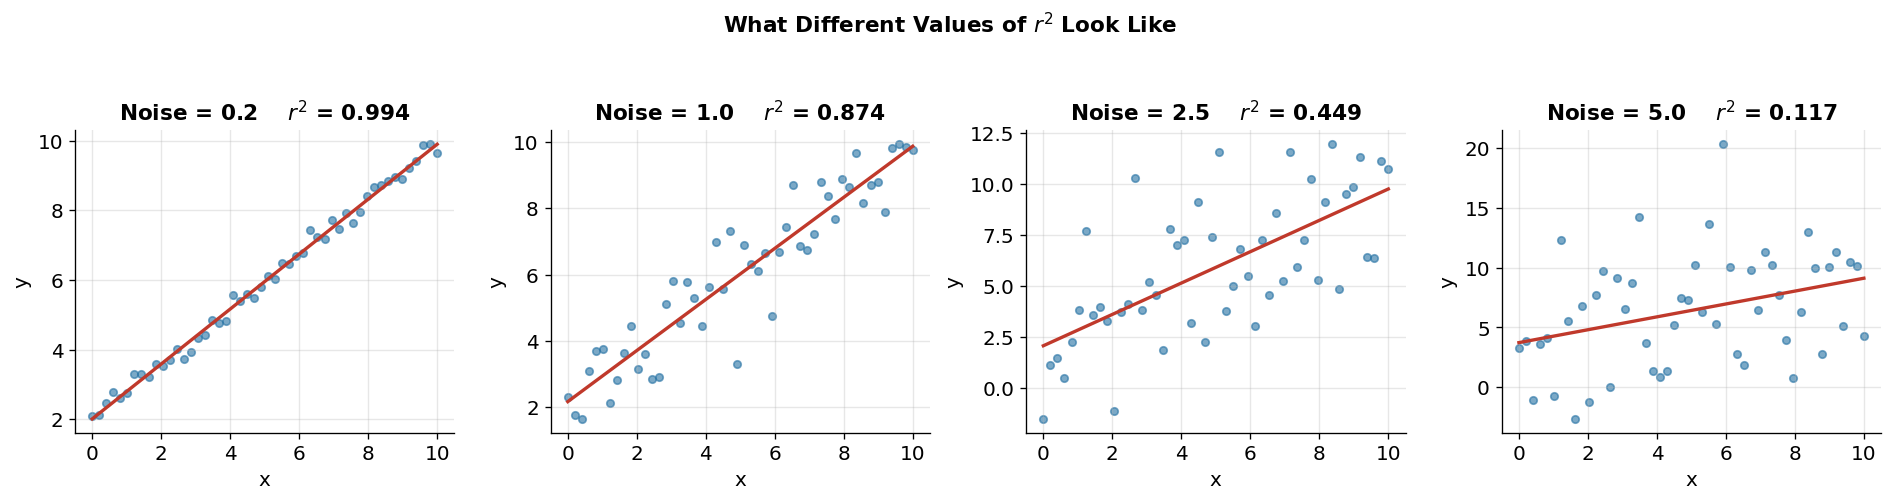

In [10]:
# ── Effect of r² on prediction quality ─────────────────────────────────────
# Simulate datasets with different r values to show what they look like

np.random.seed(42)
n_sim = 50
x_sim = np.linspace(0, 10, n_sim)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
noise_levels = [0.2, 1.0, 2.5, 5.0]

for ax, noise in zip(axes, noise_levels):
    y_sim = 2 + 0.8*x_sim + np.random.normal(0, noise, n_sim)
    a0s, a1s = least_squares_line(x_sim, y_sim)
    errs = regression_errors(x_sim, y_sim, a0s, a1s)

    ax.scatter(x_sim, y_sim, color=BLUE, s=20, alpha=0.6)
    ax.plot(x_sim, a0s + a1s*x_sim, color=RED, lw=2)
    ax.set_title(
        f'Noise = {noise}    $r^2$ = {errs["r2"]:.3f}',
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('What Different Values of $r^2$ Look Like',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
fig.savefig(
    'r2_determination_scatter_plot.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

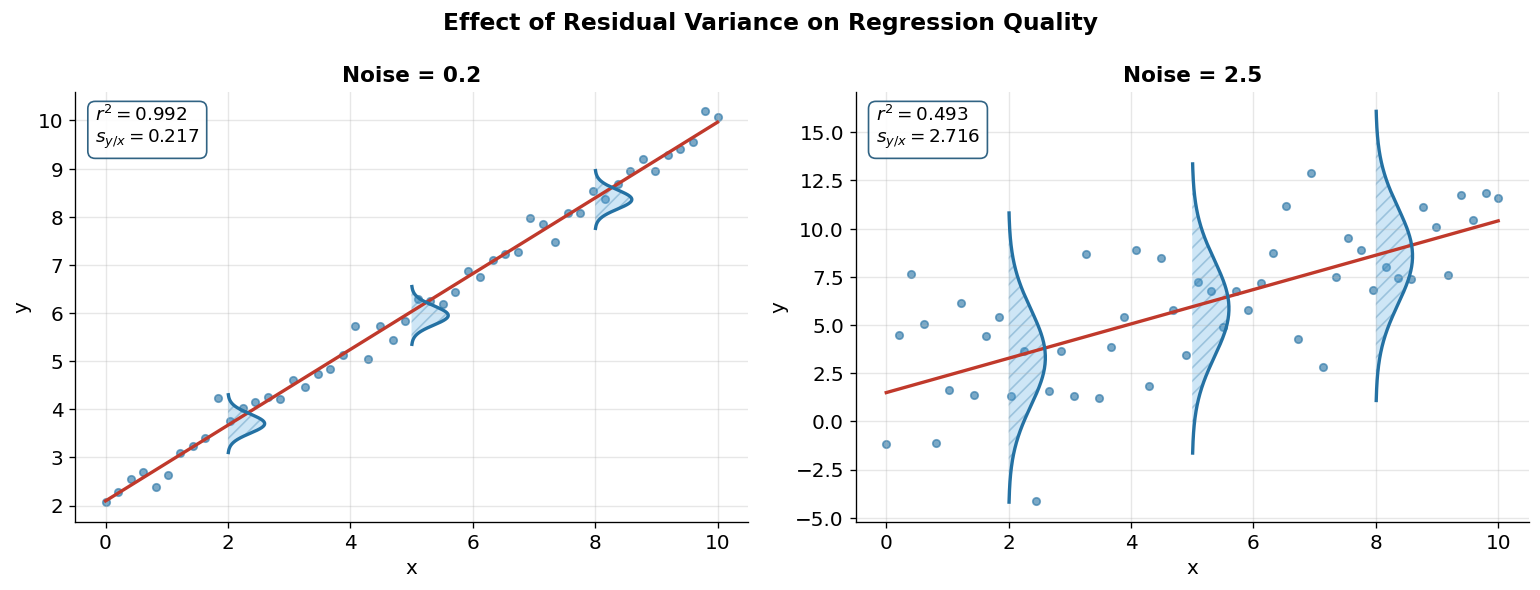

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Compare low vs high noise
noise_levels = [0.2, 2.5]

# Normal-curve locations
x_marks = [2, 5, 8]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, noise in zip(axes, noise_levels):
    y_sim = 2 + 0.8*x_sim + np.random.normal(0, noise, n_sim)
    a0s, a1s = least_squares_line(x_sim, y_sim)
    errs = regression_errors(x_sim, y_sim, a0s, a1s)
    ax.scatter(x_sim, y_sim, color=BLUE, s=20, alpha=0.6)
    ax.plot(x_sim, a0s + a1s*x_sim, color=RED, lw=2)

    yhat = a0s + a1s*x_sim

    # ── Normal curves ─────────────────────────────────
    for xm in x_marks:

        # nearest point index
        idx = np.argmin(np.abs(x_sim - xm))

        yc = yhat[idx]

        sigma = noise

        # vertical coordinate
        t = np.linspace(-3*sigma, 3*sigma, 200)

        # normal pdf
        pdf = norm.pdf(t, 0, sigma)

        # scale horizontally
        pdf = pdf / pdf.max() * 0.6

        # filled bell curve
        ax.fill_betweenx(
            yc + t,
            xm,
            xm + pdf,
            alpha=0.3,
            color='#5dade2',
            hatch='///',
            edgecolor=BLUE,
            linewidth=0
        )

        # outline
        ax.plot(
            xm + pdf,
            yc + t,
            color=BLUE,
            lw=2
        )
    # ── Statistics annotation box ───────────────────────────
    stats_text = (
        f'$r^2 = {errs["r2"]:.3f}$\n'
        f'$s_{{y/x}} = {errs["s_yx"]:.3f}$'
    )
    
    ax.text(
        0.03, 0.97,
        stats_text,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='#1a5276',
            alpha=0.9
        )
    )
    # ── Titles ────────────────────────────────────────
    
    ax.set_title(
        f'Noise = {noise}',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel('x')
    ax.set_ylabel('y')

    # textbook-style cleanup
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Main title ───────────────────────────────────────────
plt.suptitle(
    'Effect of Residual Variance on Regression Quality',
    fontsize=14,
    fontweight='bold'
)
fig.savefig(
    'residual_variance_scatter_plot.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.tight_layout()
plt.show()

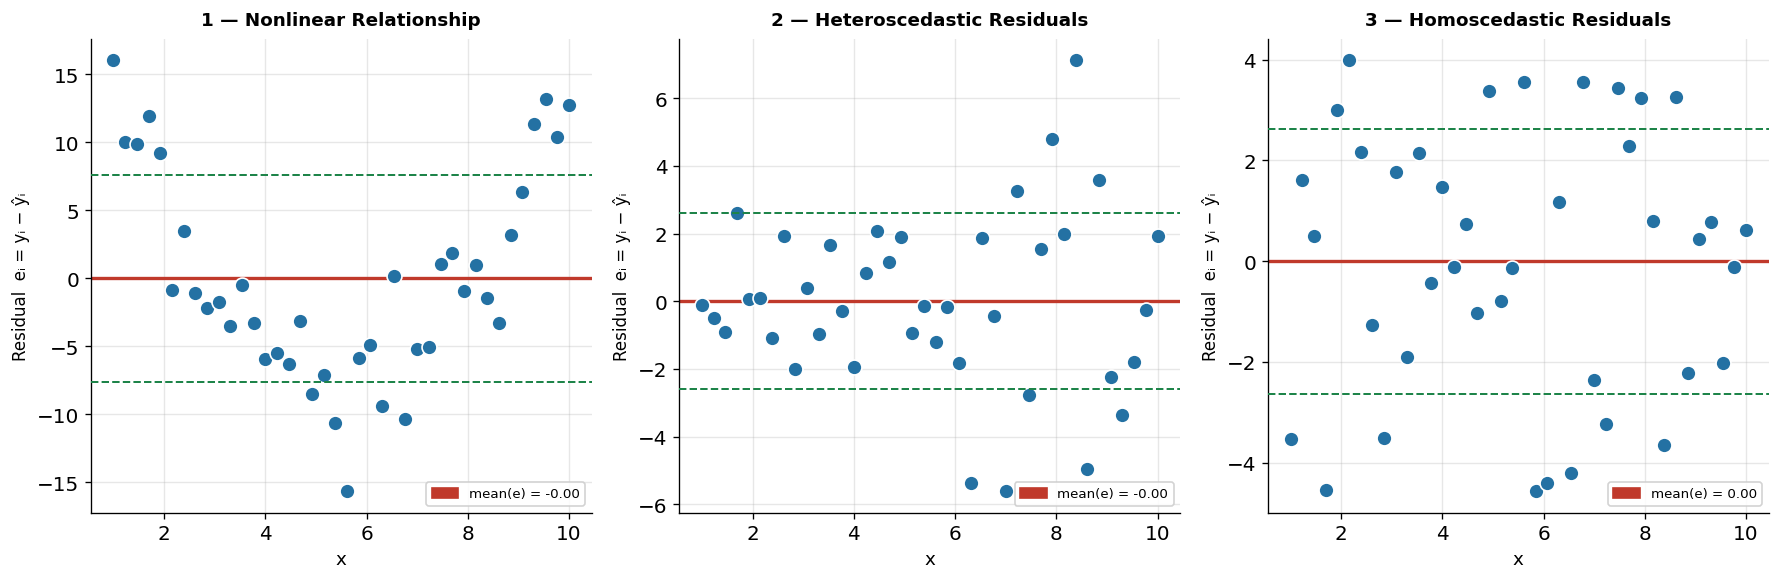

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
np.random.seed(0)
N = 40
x_sim = np.linspace(1, 10, N)
 
# ── 1. Nonlinear relationship: y = x² + noise, fitted with a straight line ──
y_nonlin = x_sim**2 + np.random.normal(0, 3, N)
a0_nl, a1_nl = least_squares_line(x_sim, y_nonlin)
errs_nl = regression_errors(x_sim, y_nonlin, a0_nl, a1_nl)
 
# ── 2. Heteroscedastic: variance grows with x ────────────────────────────────
noise_het = np.random.normal(0, 0.6 * x_sim, N)      # σ ∝ x
y_het = 3 * x_sim + 5 + noise_het
a0_ht, a1_ht = least_squares_line(x_sim, y_het)
errs_ht = regression_errors(x_sim, y_het, a0_ht, a1_ht)
 
# ── 3. Homoscedastic: constant variance (the "good" case) ────────────────────
y_homo = 3 * x_sim + 5 + np.random.normal(0, 2.5, N)
a0_hm, a1_hm = least_squares_line(x_sim, y_homo)
errs_hm = regression_errors(x_sim, y_homo, a0_hm, a1_hm)

cases = [
    dict(label='1 — Nonlinear Relationship',
         x=x_sim, e=errs_nl['residuals'],
         note='Curved pattern → model is misspecified\n(try a polynomial or log transform)'),
    dict(label='2 — Heteroscedastic Residuals',
         x=x_sim, e=errs_ht['residuals'],
         note='Fan / funnel shape → variance grows with x\n(try log(y) or weighted least squares)'),
    dict(label='3 — Homoscedastic Residuals',
         x=x_sim, e=errs_hm['residuals'],
         note='Random scatter, constant spread → ✓ Good fit\n(assumptions satisfied)'),
]
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, case in zip(axes, cases):
    x = case['x']
    e = case['e']
    mean_e = np.mean(e)
    std_e  = np.std(e, ddof=1)
 
    # ── scatter ──────────────────────────────────────────────────────────────
    ax.scatter(x, e, color=BLUE, s=80,zorder=4, edgecolors='white')
    # ── mean of residuals ─────────────────────────────────────────────────────
    ax.axhline(mean_e, color=RED, lw=2,
               label=f'mean(e) = {mean_e:.2f}')
 
    # ── ±1 std band (variance envelope) ──────────────────────────────────────
    ax.axhline( std_e, color=GREEN, linewidth=1.2,
                linestyle='--', zorder=4,
                label=f'+1σ = {std_e:.2f}')
    ax.axhline(-std_e, color=GREEN, linewidth=1.2,
                linestyle='--', zorder=4,
                label=f'−1σ = {-std_e:.2f}')
 
    # ── labels & title ────────────────────────────────────────────────────────
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('Residual  eᵢ = yᵢ − ŷᵢ', fontsize=10)
    ax.set_title(case['label'], fontsize=11, fontweight='bold', pad=8)
    # ── legend (compact) ─────────────────────────────────────────────────────
    handles = [
        mpatches.Patch(color=RED,   label=f'mean(e) = {mean_e:.2f}'),
    ]
    ax.legend(handles=handles, fontsize=8, loc='lower right'
              , framealpha=0.85)
 
plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=130,
            bbox_inches='tight')
plt.show()
 